# MiniPAR Calibration using Multi-Channel Spec
## Calibrate MiniPAR sensor using AS7341 multi-channel spectral data
This notebook reads multi-channel 'spec' output, performs multi-input linear regression against a reference PAR sensor, inspects coefficients, visualizes fit quality, analyzes channel independence, and validates the calibration.

## Setup: Imports and Helper Functions

In [4]:
import sys
import time
import serial
import glob
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')
from helpers import findDevice, get_par_MP, plot_data_and_fit, get_MP_name, r_squared

# Configuration
BAUD_RATE = 115200


## Device Discovery
Automatically detect MiniPAR, reference sensor, and DC source ports, or specify manually.

In [8]:
# clear ports

PORT_MINIPAR = None
PORT_REF = None


In [10]:
# Try auto-detection
print("Scanning for MiniPAR...")

print("\nScanning for reference sensor (TIA)...")
if not PORT_REF:
    PORT_REF = findDevice(question="\x01", answer="raw", flush=True, timeout=2)
    if(PORT_REF):
        with serial.Serial(PORT_REF) as ser:
            ser.write("\x02\x04".encode())
            ser.flush()
if not PORT_REF:
    print("Reference sensor not found. Set PORT_REF manually in next cell.")

if not PORT_MINIPAR:
    PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)
if not PORT_MINIPAR:
    print("MiniPAR not found. Set PORT_MINIPAR manually in next cell.")



print(f"\nPORT_MINIPAR: {PORT_MINIPAR}")
print(f"PORT_REF: {PORT_REF}")


Scanning for MiniPAR...

Scanning for reference sensor (TIA)...
Received message: MiniPAR,1.1, port: /dev/ttyACM1
Found device at: /dev/ttyACM1, answer: MiniPAR,1.1


PORT_MINIPAR: /dev/ttyACM1
PORT_REF: /dev/ttyACM0


In [239]:
# Uncomment and set if auto-detection fails
# PORT_MINIPAR = "/dev/ttyUSB0"
# PORT_DC = "/
# Verify ports are set
assert PORT_MINIPAR, "PORT_MINIPAR not set"
assert PORT_REF, "PORT_REF not set"
print(f"Using MiniPAR at {PORT_MINIPAR}, Reference at {PORT_REF}")

Using MiniPAR at /dev/ttyACM1, Reference at /dev/ttyACM0


## Serial Communication Functions

In [12]:
def get_spec(port):
    """Request 'spec' from MiniPAR and return list of channel floats."""
    with serial.Serial(port, baudrate=BAUD_RATE, timeout=1) as ser:
        ser.reset_input_buffer()
        ser.write("spec_raw\n".encode())
        time.sleep(0.2)
        line = ser.readline().decode(errors='ignore').strip()
    if not line:
        raise RuntimeError(f"No response from {port}")
    
    parts = [p.strip() for p in line.split(',') if p.strip()]
    # Skip device name if present
    try:
        if parts[0] and not parts[0][0].isdigit():
            parts = parts[1:]
    except Exception:
        pass
    
    return np.array([float(x) for x in parts], dtype=float)


def getPAR_TIA(port):
    with serial.Serial(port) as ser:
        ser.flush()
        ser.write("getPAR()\r".encode())
        response = ser.readline()# skip echo
        #print(response)
        response = ser.readline()
        #print(response)
    return float(response)




print("Serial functions loaded.")

print(getPAR_TIA(PORT_REF))
print(get_par_MP(PORT_MINIPAR, raw=False))
print(get_spec(PORT_MINIPAR))


Serial functions loaded.
7.2054504
6.99
[ 1.  4.  5.  7. 10. 12. 13.  8. 30.  3.]


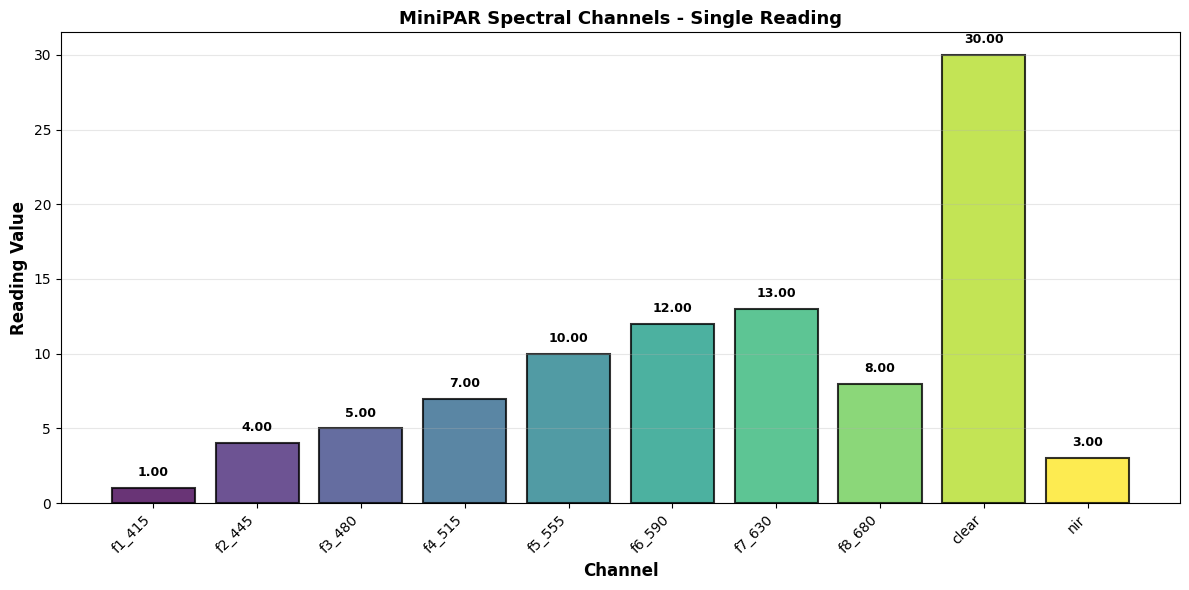


Channel readings:
  f1_415: 1.0000
  f2_445: 4.0000
  f3_480: 5.0000
  f4_515: 7.0000
  f5_555: 10.0000
  f6_590: 12.0000
  f7_630: 13.0000
  f8_680: 8.0000
  clear: 30.0000
  nir: 3.0000

Number of channels: 10


In [13]:
# test reading
single_reading = get_spec(PORT_MINIPAR)

all_channel_names = ["f1_415", "f2_445", "f3_480", "f4_515",
                     "f5_555", "f6_590", "f7_630", "f8_680",
                     "clear",  "nir"]

# Display channel readings on bar graph
fig, ax = plt.subplots(figsize=(12, 6))
channels = np.arange(1, len(single_reading) + 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(single_reading)))
bars = ax.bar(channels, single_reading, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, single_reading)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(single_reading)*0.02, 
            f'{value:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
ax.set_ylabel('Reading Value', fontsize=12, fontweight='bold')
ax.set_title('MiniPAR Spectral Channels - Single Reading', fontsize=13, fontweight='bold')
ax.set_xticks(channels)
ax.set_xticklabels(all_channel_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nChannel readings:")
for name, value in zip(all_channel_names, single_reading):
    print(f"  {name}: {value:.4f}")
print(f"\nNumber of channels: {len(single_reading)}")


Manual collection ready.
Saved readings file: manual_spec_readings.csv


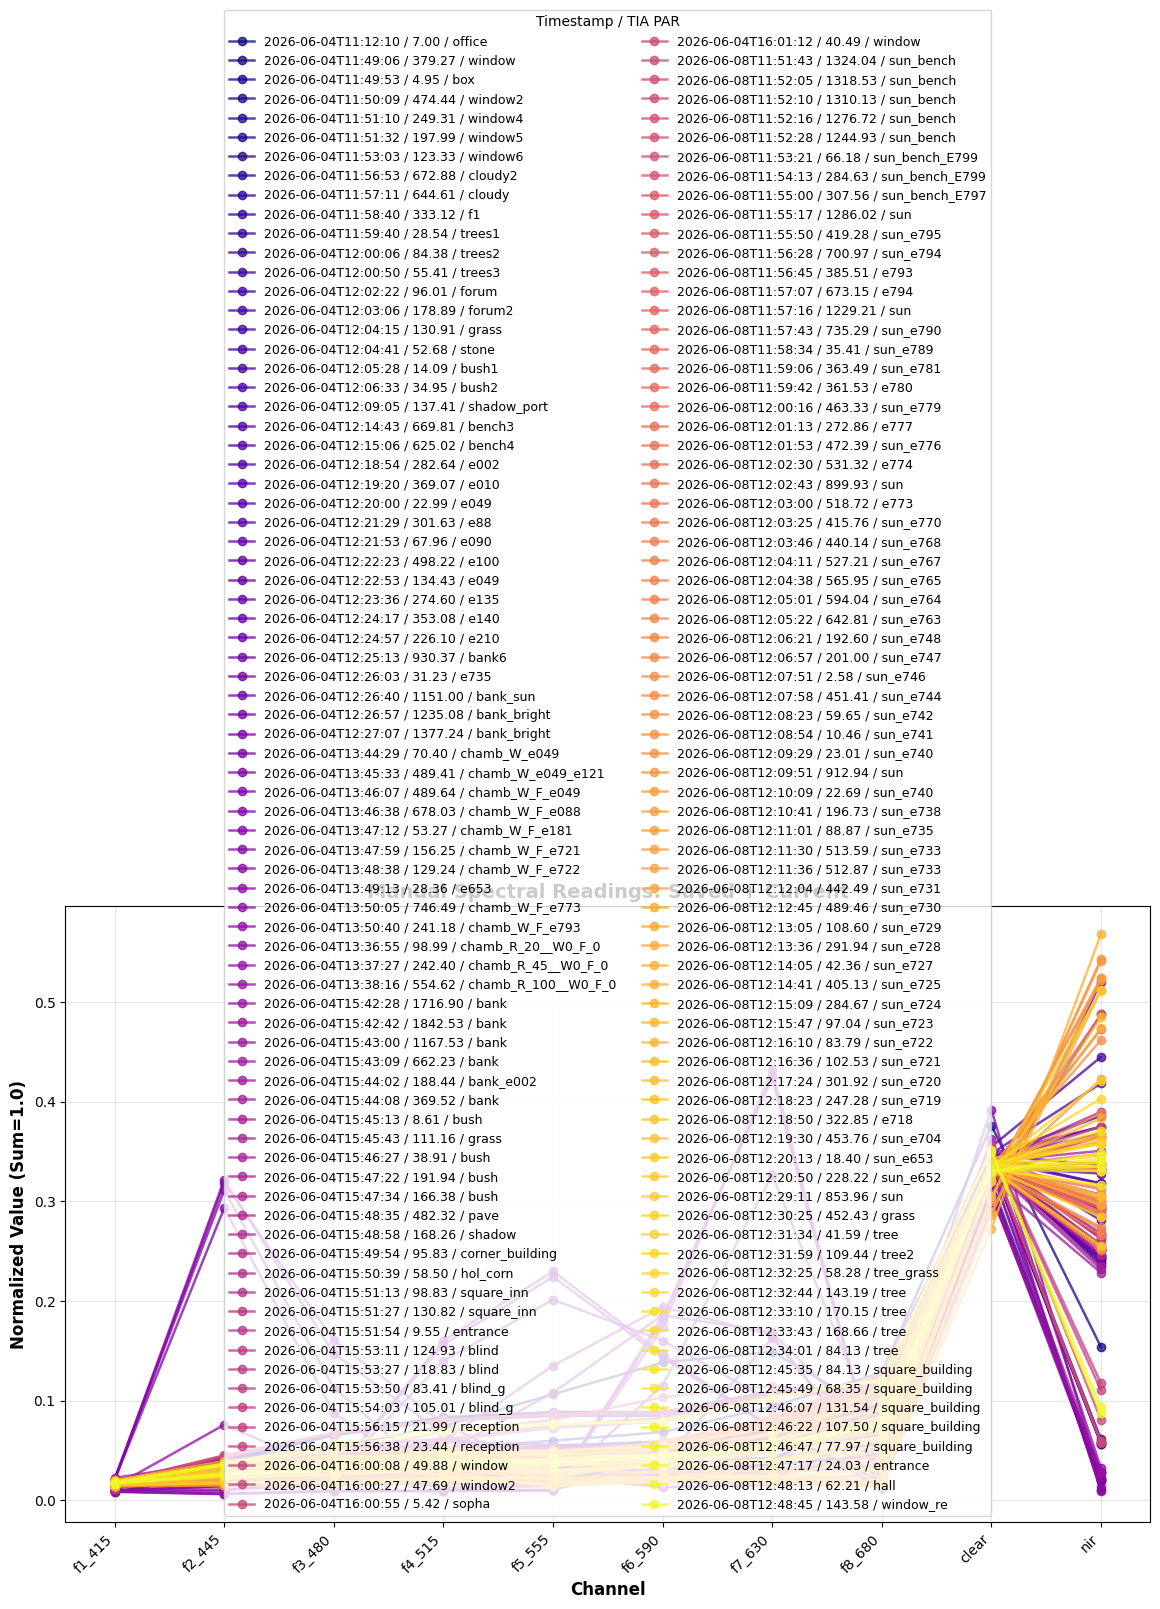

KeyboardInterrupt: Interrupted by user

In [19]:
# collect data manually by changing light and recording PAR from TIA and spec from MiniPAR
csv_path = 'manual_spec_readings.csv'
manual_channel_names = ['f1_415', 'f2_445', 'f3_480', 'f4_515',
                         'f5_555', 'f6_590', 'f7_630', 'f8_680',
                         'clear',  'nir']

from IPython.display import clear_output

def load_manual_readings(path):
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
        except Exception as e:
            raise RuntimeError(f'Could not read {path}: {e}')
    else:
        df = pd.DataFrame(columns=['timestamp', 'tia_par', 'filter_name'] + manual_channel_names)
    if 'filter_name' not in df.columns:
        df['filter_name'] = ''
    return df

def plot_manual_spectra(df, current_spec=None, current_label=None, skip_last_channels=2):
    channel_names = manual_channel_names[:-skip_last_channels] if skip_last_channels > 0 else manual_channel_names
    selected_names = manual_channel_names[:-skip_last_channels] if skip_last_channels > 0 else manual_channel_names
    fig, ax = plt.subplots(figsize=(14, 8))
    plotted = False

    if not df.empty:
        norm_df = df[selected_names].div(df[selected_names].sum(axis=1), axis=0)
        colors = plt.cm.plasma(np.linspace(0, 1, len(norm_df)))
        for plot_idx, (row_idx, row) in enumerate(norm_df.iterrows()):
            filter_name = df.loc[row_idx, 'filter_name'] if 'filter_name' in df.columns else ''
            label = f'{df.loc[row_idx, "timestamp"]} / {df.loc[row_idx, "tia_par"]:.2f}'
            if filter_name:
                label += f' / {filter_name}'
            ax.plot(np.arange(1, len(row) + 1), row.values, marker='o', linewidth=1.8, markersize=6,
                    alpha=0.75, color=colors[plot_idx], label=label)
            plotted = True

    if current_spec is not None:
        spec_arr = np.array(current_spec, dtype=float)
        if skip_last_channels > 0:
            spec_arr = spec_arr[:-skip_last_channels]
        if spec_arr.sum() != 0:
            spec_plot = spec_arr / spec_arr.sum()
        else:
            spec_plot = spec_arr
        ax.plot(np.arange(1, len(spec_plot) + 1), spec_plot, marker='o', linewidth=3, markersize=8,
                color='black', label=current_label or 'Current reading')
        plotted = True

    if not plotted:
        print('No spectral data to display yet.')
        return

    ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Value (Sum=1.0)', fontsize=12, fontweight='bold')
    ax.set_title('Manual Spectral Readings: Saved + Current', fontsize=14, fontweight='bold')
    ax.set_xticks(np.arange(1, len(channel_names) + 1))
    ax.set_xticklabels(channel_names, rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Timestamp / TIA PAR', fontsize=9, title_fontsize=10, loc='best', ncol=2)
    plt.tight_layout()
    plt.show()

def append_manual_reading(path, row):
    row_df = pd.DataFrame([row])
    if not os.path.exists(path):
        row_df.to_csv(path, index=False)
    else:
        row_df.to_csv(path, index=False, header=False, mode='a')

manual_df = load_manual_readings(csv_path)
print('Manual collection ready.')
print(f'Saved readings file: {csv_path}')
plot_manual_spectra(manual_df,skip_last_channels=0)

while True:
    user_input = input('Press Enter to capture next reading, or type esc + Enter to exit: ').strip().lower()
    if user_input in {'esc', 'exit', 'quit'}:
        print('Exiting manual collection loop.')
        break

    try:
        tia_value = getPAR_TIA(PORT_REF)
        spec_values = get_spec(PORT_MINIPAR)
    except Exception as e:
        print(f'Read error: {e}')
        continue

    clear_output(wait=True)
    print(f'TIA PAR reading: {tia_value:.6f}')
    plot_manual_spectra(manual_df, current_spec=spec_values, current_label=f'Current @ {tia_value:.2f}',skip_last_channels=0)

    filter_name = input('Enter filter name to save this reading (leave blank to reject): ').strip()
    if not filter_name:
        print('No filter name entered; reading rejected.')
        plot_manual_spectra(manual_df, current_spec=spec_values, current_label=f'Current @ {tia_value:.2f}')
        continue

    new_row = {'timestamp': pd.Timestamp.now().isoformat(timespec='seconds'), 'tia_par': float(tia_value), 'filter_name': filter_name}
    new_row.update({name: float(val) for name, val in zip(manual_channel_names, spec_values)})
    append_manual_reading(csv_path, new_row)
    manual_df = pd.concat([manual_df, pd.DataFrame([new_row])], ignore_index=True)
    clear_output(wait=True)
    print(f'Reading saved to {csv_path}')
    plot_manual_spectra(manual_df)


## Data Collection
Collect spectral data and reference PAR values across multiple current levels.

In [ ]:
# Preview saved manual spec readings
def preview_manual_readings(path='manual_spec_readings.csv', n=10):
    if not os.path.exists(path):
        print(f'No manual readings file found at {path}')
        return None
    df = pd.read_csv(path)
    if df.empty:
        print(f'{path} is empty')
        return df
    print(f'Preview first {n} rows from {path} (total rows: {len(df)})')
    print(df.head(n).to_string(index=False))
    return df

# Call the helper to preview the CSV contents
preview_manual_readings()


## Linear Regression: Multiple Input Channels

Loaded 154 manual readings from manual_spec_readings.csv for regression.
LINEAR REGRESSION RESULTS

Matrix rank: 11 / 10
Residual norm: 63751.5

Fit Quality:
  R²: 0.99711365
  RMSE: 20.346276

Coefficients:
  Channel 1: 2.2944651
  Channel 2: 0.23076731
  Channel 3: -0.074719884
  Channel 4: 0.37714843
  Channel 5: 0.049503735
  Channel 6: 0.26108017
  Channel 7: 0.14702589
  Channel 8: 0.11717859
  Channel 9: -0.20346279
  Channel 10: 0.008206926
  Intercept:  5.757317


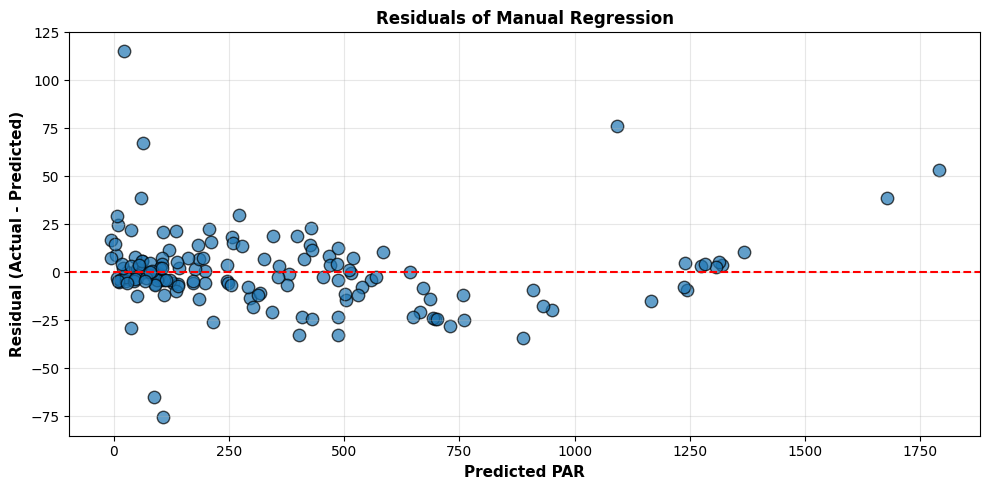

In [15]:
def load_manual_regression(path='manual_spec_readings.csv', channel_names=None):
    df = load_manual_readings(path)
    if df.empty:
        raise ValueError(f"No manual regression data found in {path}")
    if channel_names is None:
        channel_names = manual_channel_names
    missing = [c for c in channel_names if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected spectral columns in {path}: {missing}")
    X = df[channel_names].astype(float).to_numpy()
    y = df['tia_par'].astype(float).to_numpy()
    return X, y, df


X, y, df = load_manual_regression(csv_path, manual_channel_names)
X = X[:, 0:10]  # Use only the first 10 channels for regression

X_manual = X

y_manual = y
print(f"Loaded {X_manual.shape[0]} manual readings from {csv_path} for regression.")

def compute_coeffs(X, y):
    """Fit multi-input linear regression: y ≈ X @ c + intercept"""
    A = np.hstack([X, np.ones((X.shape[0], 1))])  # [ch1, ch2, ..., 1]
    coeffs, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
    return coeffs, residuals, rank, s


def r_squared(y_true, y_pred):
    """Calculate R² fit quality."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    return 1 - ss_res / ss_tot


# Perform regression
coeffs, residuals, rank, s = compute_coeffs(X, y)
intercept = coeffs[-1]
channels_coeffs = coeffs[:-1]

y_pred = (X @ channels_coeffs) + intercept
r2 = r_squared(y, y_pred)
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"\nMatrix rank: {rank} / {X.shape[1]}")
print(f"Residual norm: {np.linalg.norm(residuals):.6g}")
print(f"\nFit Quality:")
print(f"  R²: {r2:.8g}")
print(f"  RMSE: {rmse:.8g}")
print(f"\nCoefficients:")
for i, c in enumerate(channels_coeffs, start=1):
    print(f"  Channel {i}: {c:.8g}")
print(f"  Intercept:  {intercept:.8g}")
print("=" * 60)

# Residual plot
residuals = y - y_pred
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_pred, residuals, s=80, alpha=0.7, edgecolors='k', linewidth=1)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted PAR', fontsize=11, fontweight='bold')
ax.set_ylabel('Residual (Actual - Predicted)', fontsize=11, fontweight='bold')
ax.set_title('Residuals of Manual Regression', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [24]:
# Display fit coefficients, 95% relative SEs and parameter covariance
import numpy as np
import pandas as pd
from math import sqrt
try:
    from scipy import stats
    t_crit = stats.t.ppf(0.975, df=max(1, X.shape[0] - (X.shape[1] + 1)))
except Exception:
    # fallback approximate 95% critical value
    t_crit = 1.96
# Reconstruct design matrix used in regression (X currently is used for regression)
A = np.hstack([X, np.ones((X.shape[0], 1))])
n, p = A.shape
# Residuals and sigma^2 estimate
resid = (y - y_pred) if 'y' in globals() else (y_manual - y_pred)
SSR = float(np.sum(resid**2))
dof = max(1, n - p)
sigma2 = SSR / dof
# Covariance matrix of parameters
try:
    ATA_inv = np.linalg.inv(A.T.dot(A))
except np.linalg.LinAlgError:
    ATA_inv = np.linalg.pinv(A.T.dot(A))
cov_matrix = sigma2 * ATA_inv
# coefficients vector (including intercept)
params = np.concatenate([channels_coeffs, np.array([intercept])])
param_names = [f'ch{i+1}' for i in range(len(channels_coeffs))] + ['intercept']
se = np.sqrt(np.abs(np.diag(cov_matrix)))
# relative standard error expressed using 95% CI half-width divided by coef magnitude (in %).
rel_se_pct = np.full_like(se, np.nan, dtype=float)
for i, (coef, s_e) in enumerate(zip(params, se)):
    if abs(coef) > 0:
        rel_se_pct[i] = (t_crit * s_e / abs(coef)) * 100.0
# Build DataFrame for display
df_params = pd.DataFrame({
    'param': param_names,
    'coef': params,
    'std_err': se,
    '95ci_halfwidth': t_crit * se,
    'rel_se_pct_95': rel_se_pct
})
# display nicely
print('Fit parameters and 95% relative standard errors (percent):')
display(df_params[['param','coef','std_err','95ci_halfwidth','rel_se_pct_95']])

print('Correlation coefficients between parameters:')
diag = np.sqrt(np.abs(np.diag(cov_matrix)))
outer = np.outer(diag, diag)
with np.errstate(divide='ignore', invalid='ignore'):
    corr_matrix = cov_matrix / outer
corr_matrix[outer == 0] = np.nan
corr_df = pd.DataFrame(corr_matrix, index=param_names, columns=param_names)
display(corr_df.round(6))


Fit parameters and 95% relative standard errors (percent):


,param,coef,std_err,95ci_halfwidth,rel_se_pct_95
0,ch1,2.294465,0.188625,0.372854,16.250155
1,ch2,0.230767,0.037485,0.074097,32.108793
2,ch3,-0.074720,0.058379,0.115397,154.439070
3,ch4,0.377148,0.056005,0.110705,29.353259
4,ch5,0.049504,0.055947,0.110590,223.397878
5,ch6,0.261080,0.043663,0.086308,33.058026
6,ch7,0.147026,0.019377,0.038302,26.050972
7,ch8,0.117179,0.013387,0.026463,22.583425
8,ch9,-0.203463,0.016502,0.032620,16.032417
9,ch10,0.008207,0.007039,0.013913,169.531020


Correlation coefficients between parameters:


,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,intercept
ch1,1.000000,-0.053281,-0.561774,0.239669,-0.109929,0.133004,-0.018387,-0.054223,-0.428589,-0.087772,0.042931
ch2,-0.053281,1.000000,-0.583864,0.476581,-0.254590,0.131259,-0.015329,0.241927,-0.181249,0.144605,-0.224041
ch3,-0.561774,-0.583864,1.000000,-0.783581,0.590705,-0.332013,0.306481,0.063121,0.053788,0.337552,0.226681
ch4,0.239669,0.476581,-0.783581,1.000000,-0.877083,0.637617,-0.519290,0.259668,-0.103271,-0.169247,-0.109043
ch5,-0.109929,-0.254590,0.590705,-0.877083,1.000000,-0.837442,0.808939,-0.115135,-0.151914,0.380659,0.101856
ch6,0.133004,0.131259,-0.332013,0.637617,-0.837442,1.000000,-0.860902,0.376045,-0.142014,-0.053472,0.021981
ch7,-0.018387,-0.015329,0.306481,-0.519290,0.808939,-0.860902,1.000000,-0.050647,-0.287335,0.442783,0.038004
ch8,-0.054223,0.241927,0.063121,0.259668,-0.115135,0.376045,-0.050647,1.000000,-0.760908,0.760353,0.326969
ch9,-0.428589,-0.181249,0.053788,-0.103271,-0.151914,-0.142014,-0.287335,-0.760908,1.000000,-0.836592,-0.261726
ch10,-0.087772,0.144605,0.337552,-0.169247,0.380659,-0.053472,0.442783,0.760353,-0.836592,1.000000,0.195437


In [ ]:
## Regressionanalysis with multiple input channels - display top outliers by absolute fit error

In [9]:
# Display top manual regression outliers by absolute fit error
outlier_df = df.copy()
outlier_df['predicted_par'] = y_pred
outlier_df['residual'] = y - y_pred
outlier_df['abs_error'] = np.abs(outlier_df['residual'])
outlier_df['filter_name'] = outlier_df.get('filter_name', '').fillna('').astype(str)
outlier_df = outlier_df.sort_values('abs_error', ascending=False)
print(f'Loaded {len(outlier_df)} manual readings, showing top outliers by fit error:')
display(outlier_df[['timestamp', 'filter_name', 'tia_par', 'predicted_par', 'residual', 'abs_error']].head(10))


Loaded 78 manual readings, showing top outliers by fit error:


,timestamp,filter_name,tia_par,predicted_par,residual,abs_error
19,2026-06-04T12:09:05,shadow_port,137.414680,21.155961,116.258719,116.258719
66,2026-06-04T15:51:27,square_inn,130.821800,62.259662,68.562138,68.562138
24,2026-06-04T12:20:00,e049,22.987702,88.769867,-65.782165,65.782165
33,2026-06-04T12:26:03,e735,31.228792,82.206502,-50.977710,50.977710
51,2026-06-04T15:42:42,bank,1842.529840,1796.964717,45.565123,45.565123
25,2026-06-04T12:21:29,e88,301.626840,258.916880,42.709960,42.709960
65,2026-06-04T15:51:13,square_inn,98.828310,58.754018,40.074292,40.074292
55,2026-06-04T15:44:08,bank,369.519880,406.839838,-37.319958,37.319958
31,2026-06-04T12:24:57,e210,226.102340,194.404240,31.698100,31.698100
50,2026-06-04T15:42:28,bank,1716.904200,1685.980950,30.923250,30.923250


Normalized 105 samples to 100.0 (threshold=100.0)
X_norm shape: (154, 10)

NORMALIZED-THRESHOLD REGRESSION RESULTS
Normalized-space fit: R² = 0.848755, RMSE = 11.331
Rescaled (original units) fit: R² = 0.995967, RMSE = 24.0517
Number of normalized samples: 105


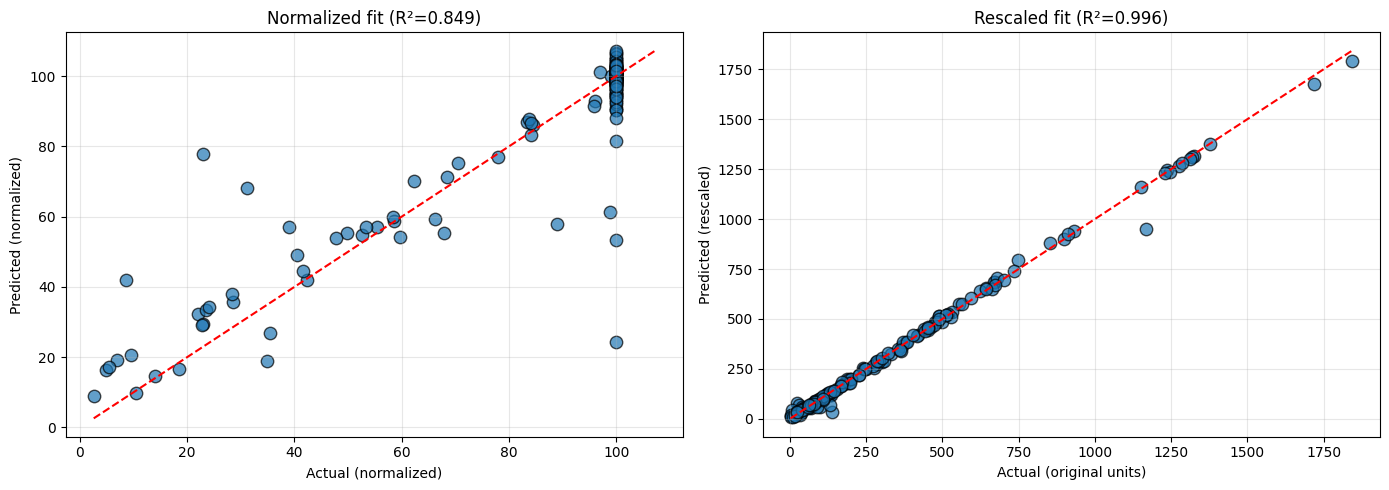

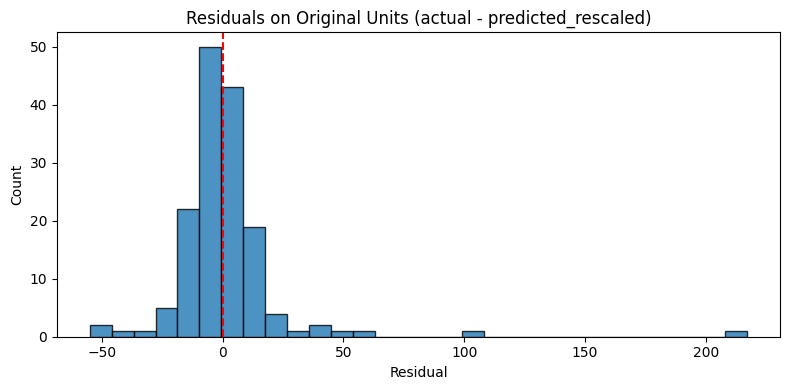


Coefficients (from regression on threshold-normalized data):
  Channel 1: 0.79515256
  Channel 2: 0.13396137
  Channel 3: 0.23246439
  Channel 4: 0.0055369149
  Channel 5: 0.27511726
  Channel 6: 0.063787768
  Channel 7: 0.16059389
  Channel 8: 0.047807888
  Channel 9: -0.086809668
  Channel 10: -0.0044805649
  Intercept: 13.092959

Note: coefficients are estimated on mixed normalized/unnormalized data. To interpret in original units, predictions are rescaled per-sample as shown above.


In [20]:
# Normalized Regression: Thresholded normalization and rescaled evaluation
# Apply normalization only to samples with measured PAR above a selected value (e.g. 100)
selected_value = 100.0  # target value to normalize to
threshold = selected_value

# Prepare normalized dataset (copy of original)
X_norm = X_manual.copy()
y_norm = y_manual.copy()
scales = np.ones(len(y_manual), dtype=float)  # per-sample channel scaling factor

# Normalize only samples with measured PAR > threshold
for i in range(X_norm.shape[0]):
    if y_manual[i] > threshold and y_manual[i] > 0:
        scale = selected_value / float(y_manual[i])
        X_norm[i, :] = X_norm[i, :] * scale
        y_norm[i] = selected_value
        scales[i] = scale
    else:
        # leave sample unchanged (scale = 1)
        scales[i] = 1.0

print(f'Normalized {int(np.sum(scales!=1))} samples to {selected_value} (threshold={threshold})')
print(f'X_norm shape: {X_norm.shape}')

# Perform regression on mixed (threshold-normalized) data
coeffs_norm, residuals_norm, rank_norm, s_norm = compute_coeffs(X_norm, y_norm)
intercept_norm = coeffs_norm[-1]
channels_coeffs_norm = coeffs_norm[:-1]

# Predictions in normalized space
y_pred_norm = (X_norm @ channels_coeffs_norm) + intercept_norm
r2_norm = r_squared(y_norm, y_pred_norm)
rmse_norm = np.sqrt(np.mean((y_norm - y_pred_norm) ** 2))

# Rescale normalized predictions back to original units per-sample
# For samples that were scaled by 'scale = selected_value / y_orig', the model
# predicts in normalized units. To recover original units: y_orig_pred = y_pred_norm / scale
predicted_rescaled = y_pred_norm / scales

# Evaluate performance on original (unnormalized) data
r2_rescaled = r_squared(y_manual, predicted_rescaled)
rmse_rescaled = np.sqrt(np.mean((y_manual - predicted_rescaled) ** 2))
residuals_original = y_manual - predicted_rescaled

print('\n' + '=' * 60)
print('NORMALIZED-THRESHOLD REGRESSION RESULTS')
print('=' * 60)
print(f'Normalized-space fit: R² = {r2_norm:.6g}, RMSE = {rmse_norm:.6g}')
print(f'Rescaled (original units) fit: R² = {r2_rescaled:.6g}, RMSE = {rmse_rescaled:.6g}')
print(f'Number of normalized samples: {int(np.sum(scales!=1))}')

# Plots: normalized fit diagnostics and rescaled residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Normalized predicted vs normalized actual
ax = axes[0]
ax.scatter(y_norm, y_pred_norm, s=80, alpha=0.7, edgecolors='k')
lims = [np.min([y_norm.min(), y_pred_norm.min()]), np.max([y_norm.max(), y_pred_norm.max()])]
ax.plot(lims, lims, 'r--', lw=1.5)
ax.set_xlabel('Actual (normalized)')
ax.set_ylabel('Predicted (normalized)')
ax.set_title(f'Normalized fit (R²={r2_norm:.3f})')
ax.grid(True, alpha=0.3)

# Plot 2: Rescaled predicted vs actual (original units)
ax = axes[1]
ax.scatter(y_manual, predicted_rescaled, s=80, alpha=0.7, edgecolors='k')
lims2 = [np.min([y_manual.min(), predicted_rescaled.min()]), np.max([y_manual.max(), predicted_rescaled.max()])]
ax.plot(lims2, lims2, 'r--', lw=1.5)
ax.set_xlabel('Actual (original units)')
ax.set_ylabel('Predicted (rescaled)')
ax.set_title(f'Rescaled fit (R²={r2_rescaled:.3f})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual histogram on original units
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals_original, bins=30, alpha=0.8, edgecolor='k')
ax.axvline(0, color='r', linestyle='--')
ax.set_title('Residuals on Original Units (actual - predicted_rescaled)')
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Show coefficients (normalized-space) and note about interpretation
print('\nCoefficients (from regression on threshold-normalized data):')
for i, c in enumerate(channels_coeffs_norm, start=1):
    print(f'  Channel {i}: {c:.8g}')
print(f'  Intercept: {intercept_norm:.8g}')
print('\nNote: coefficients are estimated on mixed normalized/unnormalized data. To interpret in original units, predictions are rescaled per-sample as shown above.')


## Linear Regression: Multiple Input Channels

## Analysis: influence

In [ ]:
# DFBETAS selection: identify the most influential points for each fit parameter

def compute_dfbetas(X, y):
    A = np.hstack([X, np.ones((X.shape[0], 1))])
    coeffs_full, _, _, _ = compute_coeffs(X, y)
    n, p = A.shape
    y_pred_full = A.dot(coeffs_full)
    ss_res = np.sum((y - y_pred_full) ** 2)
    sigma2 = ss_res / max(1, n - p)
    cov = np.linalg.pinv(A.T.dot(A)) * sigma2
    se_full = np.sqrt(np.abs(np.diag(cov)))
    dfbetas = np.zeros((n, p))
    for i in range(n):
        X_i = np.delete(X, i, axis=0)
        y_i = np.delete(y, i)
        coeffs_i, _, _, _ = compute_coeffs(X_i, y_i)
        dfbetas[i] = (coeffs_i - coeffs_full) / np.where(se_full == 0, 1e-12, se_full)
    return dfbetas, coeffs_full, se_full

param_names = [f'ch{i+1}' for i in range(X_full.shape[1])] + ['intercept']
dfbetas, full_coeffs, se_full = compute_dfbetas(X_full, y_full)

# Select the most important points for each parameter
TOP_N_PER_PARAM = 4
selected_indices = set()
for j, name in enumerate(param_names):
    order = np.argsort(np.abs(dfbetas[:, j]))[::-1]
    top_indices = order[:TOP_N_PER_PARAM]
    selected_indices.update(top_indices.tolist())
    print(f"Top {TOP_N_PER_PARAM} points for {name}: {top_indices.tolist()}\n  DFBETAS = {np.round(np.abs(dfbetas[top_indices, j]), 4).tolist()}\n")

selected_indices = sorted(selected_indices)
print(f"Unique selected indices across all parameters: {selected_indices} (count={len(selected_indices)})")

# Refit using only the selected influential points and evaluate on the original dataset
X_selected = X_full[selected_indices]
y_selected = y_full[selected_indices]
coeffs_selected, _, _, _ = compute_coeffs(X_selected, y_selected)
intercept_selected = coeffs_selected[-1]
channels_coeffs_selected = coeffs_selected[:-1]

y_pred_selected = X_full.dot(channels_coeffs_selected) + intercept_selected
r2_selected = r_squared(y_full, y_pred_selected)
rmse_selected = np.sqrt(np.mean((y_full - y_pred_selected) ** 2))

print('\nDFBETAS-selected regression evaluated against the original full dataset:')
print(f'  Selected point count: {len(selected_indices)}')
print(f'  R²: {r2_selected:.6f}')
print(f'  RMSE: {rmse_selected:.6g}')
print(f'  Selected coefficients: {np.round(coeffs_selected, 6).tolist()}')

if 'r2' in globals() and 'rmse' in globals():
    print(f'  Full-model R²: {r2:.6f}, RMSE: {rmse:.6g}')

# Display most influential points with details
print("\n" + "=" * 80)
print("MOST INFLUENTIAL POINTS SUMMARY")
print("=" * 80)

influence_summary = []
for idx in selected_indices:
    filter_name = df.iloc[idx].get('filter_name', '') if 'filter_name' in df.columns else ''
    par_intensity = df.iloc[idx]['tia_par'] if 'tia_par' in df.columns else y_full[idx]
    
    # Get the top influential parameters for this point
    abs_dfbetas = np.abs(dfbetas[idx])
    top_param_idx = np.argsort(abs_dfbetas)[::-1][:3]  # Top 3 influenced parameters
    influences = [(param_names[p_idx], abs_dfbetas[p_idx]) for p_idx in top_param_idx]
    
    influence_summary.append({
        'index': idx,
        'filter_name': filter_name,
        'par_intensity': par_intensity,
        'influences': influences
    })

for item in influence_summary:
    print(f"\nPoint {item['index']}:")
    print(f"  Filter Name: {item['filter_name']}")
    print(f"  PAR Intensity: {item['par_intensity']:.6f}")
    print(f"  Most Influences (top DFBETAS):")
    for param_name, dfbetas_val in item['influences']:
        print(f"    - {param_name}: {dfbetas_val:.4f}")

print("\n" + "=" * 80)


Top 4 points for ch1: [178, 208, 8, 130]
  DFBETAS = [0.2487, 0.2429, 0.2419, 0.2387]

Top 4 points for ch2: [130, 8, 208, 110]
  DFBETAS = [0.6611, 0.3882, 0.2312, 0.1793]

Top 4 points for ch3: [130, 8, 40, 59]
  DFBETAS = [0.748, 0.4594, 0.1705, 0.1493]

Top 4 points for ch4: [8, 130, 40, 178]
  DFBETAS = [0.4657, 0.3371, 0.2002, 0.1537]

Top 4 points for ch5: [178, 8, 90, 228]
  DFBETAS = [0.2933, 0.275, 0.1885, 0.1515]

Top 4 points for ch6: [178, 8, 90, 231]
  DFBETAS = [0.3609, 0.2147, 0.13, 0.1131]

Top 4 points for ch7: [130, 110, 2, 69]
  DFBETAS = [0.4318, 0.2466, 0.2138, 0.1513]

Top 4 points for ch8: [130, 110, 8, 169]
  DFBETAS = [0.4662, 0.3085, 0.1913, 0.1548]

Top 4 points for intercept: [178, 231, 8, 212]
  DFBETAS = [0.5973, 0.2126, 0.156, 0.1474]

Unique selected indices across all parameters: [2, 8, 40, 59, 69, 90, 110, 130, 169, 178, 208, 212, 228, 231] (count=14)

DFBETAS-selected regression evaluated against the original full dataset:
  Selected point count: 14


IndexError: single positional indexer is out-of-bounds

In [ ]:
# Greedy removal of influential manual regression datapoints
fraction_to_remove = 0.90  # Adjust this fraction to inspect the most influential points
n_total = X_manual.shape[0]
num_remove = max(1, int(np.ceil(n_total * fraction_to_remove)))
print(f'Greedy removal selected {num_remove} points ({fraction_to_remove*100:.1f}% of {n_total}) as most influential for coefficient estimation.')

X_full = X_manual
y_full = y_manual
full_coeffs, _, _, _ = compute_coeffs(X_full, y_full)
remaining_indices = list(range(n_total))
removed_indices = []
selected_changes = []

for remove_step in range(num_remove):
    best_idx = None
    best_change = -np.inf
    for idx in remaining_indices:
        candidate = [i for i in remaining_indices if i != idx]
        X_tmp = X_full[candidate]
        y_tmp = y_full[candidate]
        coeffs_tmp, _, _, _ = compute_coeffs(X_tmp, y_tmp)
        change = np.linalg.norm(coeffs_tmp - full_coeffs)
        if change > best_change:
            best_change = change
            best_idx = idx
    removed_indices.append(best_idx)
    selected_changes.append(best_change)
    remaining_indices.remove(best_idx)
    print(f'  Removed point {best_idx} with coefficient-change impact {best_change:.6g}')

X_reduced = X_full[remaining_indices]
y_reduced = y_full[remaining_indices]
coeffs_reduced, _, _, _ = compute_coeffs(X_reduced, y_reduced)
intercept_reduced = coeffs_reduced[-1]
channels_coeffs_reduced = coeffs_reduced[:-1]

y_pred_full = X_full.dot(channels_coeffs_reduced) + intercept_reduced
r2_full = r_squared(y_full, y_pred_full)
rmse_full = np.sqrt(np.mean((y_full - y_pred_full) ** 2))

print('\nRegression on reduced dataset (removed most influential points) evaluated against the whole dataset:')
print(f'  Remaining points: {len(remaining_indices)}')
print(f'  R² (whole dataset): {r2_full:.6f}')
print(f'  RMSE (whole dataset): {rmse_full:.6g}')

removed_df = df.iloc[removed_indices].copy()
removed_df['selected_order'] = np.arange(1, len(removed_indices) + 1)
removed_df['coeff_change'] = selected_changes
removed_df['predicted_full'] = X_full[removed_indices].dot(full_coeffs[:-1]) + full_coeffs[-1]
removed_df['residual_full'] = removed_df['tia_par'] - removed_df['predicted_full']

print('\nMost influential points removed by greedy selection:')
display(removed_df[['selected_order', 'timestamp', 'filter_name', 'tia_par', 'coeff_change', 'residual_full']])

# Optionally show the remaining data fit quality as well
y_pred_reduced = X_reduced.dot(channels_coeffs_reduced) + intercept_reduced
r2_reduced = r_squared(y_reduced, y_pred_reduced)
rmse_reduced = np.sqrt(np.mean((y_reduced - y_pred_reduced) ** 2))
print(f'\nReduced dataset fit quality: R² = {r2_reduced:.6f}, RMSE = {rmse_reduced:.6g}')


## Visualization: Fit Quality and Channel Analysis

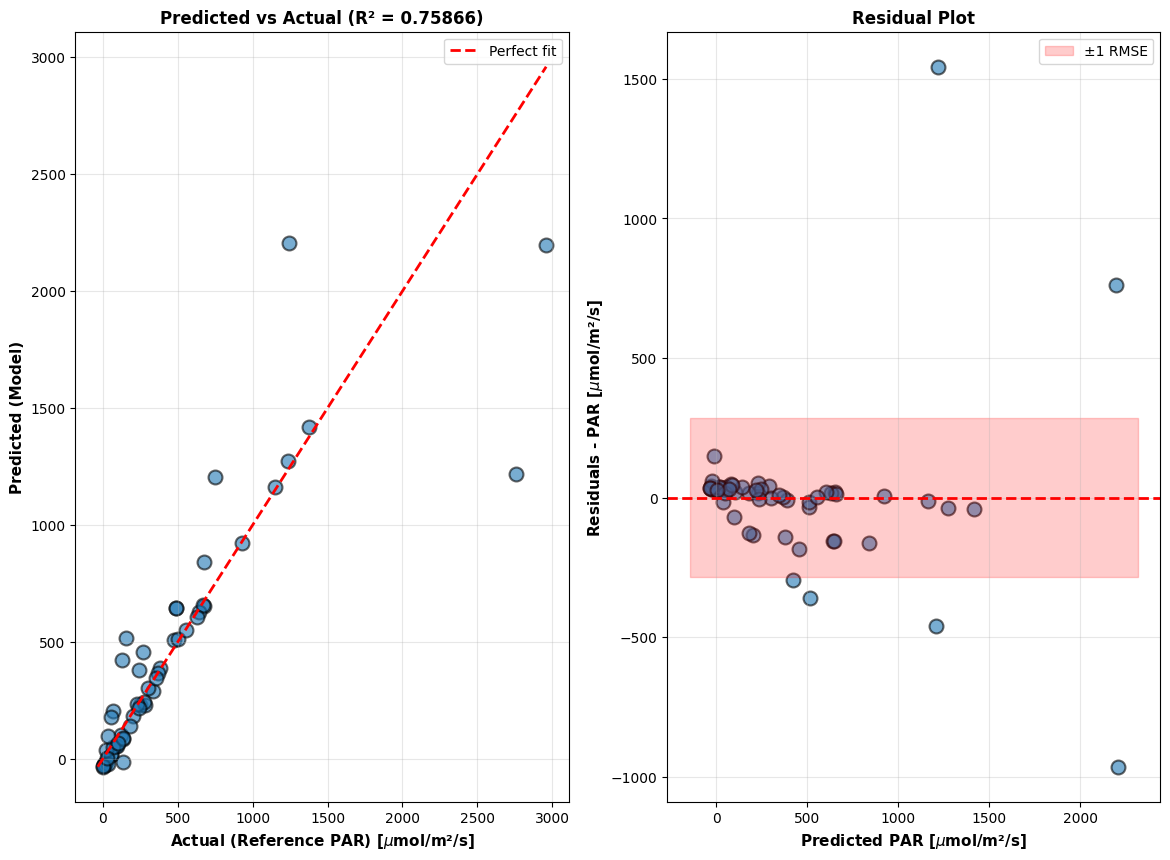

Plots saved to calibration_fit_analysis.png


In [220]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Plot 1: Predicted vs Actual using manually collected data
ax = axes[0]
ax.scatter(y_manual, y_pred, s=100, alpha=0.6, edgecolors='k', linewidth=1.5)
lims = [np.min([y_manual.min(), y_pred.min()]), np.max([y_manual.max(), y_pred.max()])]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit')
ax.set_xlabel('Actual (Reference PAR) [$\u00B5$mol/m²/s]', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted (Model)', fontsize=11, fontweight='bold')
ax.set_title(f'Predicted vs Actual (R² = {r2:.5f})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Residuals for manually collected data
ax = axes[1]
residuals_data = y_manual - y_pred
ax.scatter(y_pred, residuals_data, s=100, alpha=0.6, edgecolors='k', linewidth=1.5)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.fill_between(ax.get_xlim(), -rmse, rmse, alpha=0.2, color='red', label=f'±1 RMSE')
ax.set_xlabel('Predicted PAR [$\u00B5$mol/m²/s]', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuals - PAR [$\u00B5$mol/m²/s]', fontsize=11, fontweight='bold')
ax.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

#plt.tight_layout()
plt.savefig('calibration_fit_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plots saved to calibration_fit_analysis.png")

## Coefficient Inspection & Approval
**Review the coefficients below before uploading.** Adjust if needed.

In [18]:
# Display coefficients for inspection
print("\n" + "=" * 60)
print("CALIBRATION COEFFICIENTS FOR UPLOAD")
print("=" * 60)
coeffs_display = coeffs.copy()
print(f"\nCommand format: cal_par_coeffs,<c1>,<c2>,...,<intercept>")
print(f"\nFull coefficient array (including intercept):")
print(coeffs_display)

# CSV format for upload
coeffs_csv = ",".join([f"{c:.6g}" for c in coeffs_display])
print(f"\nCSV format for upload:")
print(coeffs_csv)

# Save to JSON for later use
coeffs_data = {
    'coeffs': coeffs_display.tolist(),
    'channel_coeffs': channels_coeffs.tolist(),
    'intercept': float(intercept),
    'r2': float(r2),
    'rmse': float(rmse),
    'condition_number': float(np.linalg.cond(X)),
    'timestamp': None  # Will be filled if uploaded
}

with open('calibration_coeffs.json', 'w') as f:
    json.dump(coeffs_data, f, indent=2)
print(f"\nCoefficients saved to calibration_coeffs.json")
print("=" * 60)


CALIBRATION COEFFICIENTS FOR UPLOAD

Command format: cal_par_coeffs,<c1>,<c2>,...,<intercept>

Full coefficient array (including intercept):
[ 2.29446507  0.23076731 -0.07471988  0.37714843  0.04950373  0.26108017
  0.14702589  0.11717859 -0.20346279  0.00820693  5.75731705]

CSV format for upload:
2.29447,0.230767,-0.0747199,0.377148,0.0495037,0.26108,0.147026,0.117179,-0.203463,0.00820693,5.75732

Coefficients saved to calibration_coeffs.json


## Upload Coefficients
**Run this cell only after reviewing the coefficients above.**

In [ ]:
# Upload channel coefficients from calibration_coeffs.json to MiniPAR
import os
import json
from helpers import findDevice

# Initialize ports for MiniPAR
PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)

coeffs_file = 'calibration_coeffs.json'

coeffs_file = 'calibration_coeffs_par_window.json'  

if not os.path.exists(coeffs_file):
    raise FileNotFoundError(f"Coefficient file not found: {coeffs_file}")

with open(coeffs_file, 'r') as f:
    saved = json.load(f)

channel_coeffs = saved.get('channel_coeffs')
if channel_coeffs is None:
    raise KeyError('Expected key "channel_coeffs" in calibration_coeffs.json')

channel_coeffs = channel_coeffs[:10]  # Ensure we only take the first 10 coefficients for MiniPAR
#channel_coeffs.append(0.0)  # Add the 9th coefficient for the default value (if needed)
#channel_coeffs.append(0.0)  # Add the 10th coefficient for the default value (if needed)

print(f"Uploading {len(channel_coeffs)} channel coefficients from {coeffs_file} to MiniPAR...")

with serial.Serial(PORT_MINIPAR,  timeout=1) as ser:
    ser.reset_input_buffer()
    for i, value in enumerate(channel_coeffs, start=0):
        cmd = f"set_spec_coeff,{i},{value:.6g}\n"
        print(f"Sending: {cmd.strip()}")
        ser.write(cmd.encode())
        ser.flush()
        time.sleep(0.1)
        resp = ser.readline().decode(errors='ignore').strip()
        print(f"Response: {resp}")
    
    print("Verifying uploaded coefficients...")
    cmd = "get_spec_coeffs\n"
    print(f"Sending: {cmd.strip()}")
    ser.write(cmd.encode())
    ser.flush()
    resp = ser.readline().decode(errors='ignore').strip()
    print(f"Received coefficients: {resp}")

print('Channel coefficient upload complete.')

Received message: MiniPAR,1.1, port: /dev/ttyACM1
Found device at: /dev/ttyACM1, answer: MiniPAR,1.1



FileNotFoundError: Coefficient file not found: callibration_coeffs_par_window.json

## Post-Validation: Verify Calibration
Compare MiniPAR 'par' readings against reference sensor at several current levels.

In [ ]:
# Wait for user to run post-validation
print("\nPost-validation requires running the calibrated device.")
print("Ensure coefficients have been uploaded and device rebooted if needed.\n")

# Test currents (subset of calibration range)
test_currents = [0.3, 0.7, 1.2]
validation_data = []

print("Running validation sweep...\n")
print(f"{'Current (A)':<15} {'Reference (PAR)':<20} {'MiniPAR (PAR)':<20} {'Error (abs)':<15} {'Error (%)':<15}")
print("-" * 85)

for I in test_currents:
    if PORT_DC:
        set_current(PORT_DC, I)
    time.sleep(1.0)
    
    try:
        ref = getPAR_TIA(PORT_REF)
        par = get_par(PORT_MINIPAR)
        error_abs = abs(par - ref)
        error_pct = (error_abs / ref * 100) if ref != 0 else 0
        
        validation_data.append({
            'current': I,
            'ref': ref,
            'par': par,
            'error_abs': error_abs,
            'error_pct': error_pct
        })
        
        print(f"{I:<15.2f} {ref:<20.4f} {par:<20.4f} {error_abs:<15.4f} {error_pct:<15.2f}%")
    except Exception as e:
        print(f"{I:<15.2f} ERROR: {e}")

if validation_data:
    errors_abs = [d['error_abs'] for d in validation_data]
    errors_pct = [d['error_pct'] for d in validation_data]
    print("-" * 85)
    print(f"{'Mean error':<15} {np.mean([d['ref'] for d in validation_data]):<20.4f} {np.mean([d['par'] for d in validation_data]):<20.4f} {np.mean(errors_abs):<15.4f} {np.mean(errors_pct):<15.2f}%")
    print("\nValidation complete.")
else:
    print("No validation data collected.")


Post-validation requires running the calibrated device.
Ensure coefficients have been uploaded and device rebooted if needed.

Running validation sweep...

Current (A)     Reference (PAR)      MiniPAR (PAR)        Error (abs)     Error (%)      
-------------------------------------------------------------------------------------


NameError: name 'PORT_DC' is not defined

## Validation Summary

In [201]:
if validation_data:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    # Plot 1: Reference vs Calibrated PAR
    ax = axes[0]
    refs = [d['ref'] for d in validation_data]
    pars = [d['par'] for d in validation_data]
    ax.scatter(refs, pars, s=150, alpha=0.7, edgecolors='k', linewidth=2)
    lims = [min(refs + pars), max(refs + pars)]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect agreement')
    ax.set_xlabel('Reference Sensor PAR', fontsize=11, fontweight='bold')
    ax.set_ylabel('MiniPAR (Calibrated) PAR', fontsize=11, fontweight='bold')
    ax.set_title('Post-Validation: MiniPAR vs Reference', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot 2: Validation Errors
    ax = axes[1]
    currents_val = [d['current'] for d in validation_data]
    errors_pct = [d['error_pct'] for d in validation_data]
    colors = ['green' if e < 5 else 'orange' if e < 10 else 'red' for e in errors_pct]
    ax.bar(range(len(currents_val)), errors_pct, color=colors, alpha=0.7, edgecolor='k', linewidth=1.5)
    ax.axhline(y=5, color='green', linestyle='--', lw=1.5, label='5% threshold')
    ax.axhline(y=10, color='orange', linestyle='--', lw=1.5, label='10% threshold')
    ax.set_xticks(range(len(currents_val)))
    ax.set_xticklabels([f"{c:.1f}A" for c in currents_val])
    ax.set_ylabel('Absolute Error (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Current', fontsize=11, fontweight='bold')
    ax.set_title('Validation Errors by Current Level', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('validation_results.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("Validation plot saved to validation_results.png")
else:
    print("No validation data to plot.")

No validation data to plot.
